In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as st
from sklearn.metrics import confusion_matrix
import matplotlib.mlab as mlab

%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
heart_df = pd.read_csv("data/framingham.csv")
heart_df.drop(['education'], axis=1, inplace=True)
heart_df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
heart_df.rename(columns={'male': 'мужчина', 'age': "Возраст", 'currentSmoker': "Курильщик", "cigsPerDay": "Сколько сигарет в день"}, inplace=True)
heart_df.head()

,мужчина,Возраст,Курильщик,Сколько сигарет в день,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
heart_df.isnull().sum()

мужчина                     0
Возраст                     0
Курильщик                   0
Сколько сигарет в день     29
BPMeds                     53
prevalentStroke             0
prevalentHyp                0
diabetes                    0
totChol                    50
sysBP                       0
diaBP                       0
BMI                        19
heartRate                   1
glucose                   388
TenYearCHD                  0
dtype: int64

In [6]:
heart_df.dropna(axis=0, inplace=True)

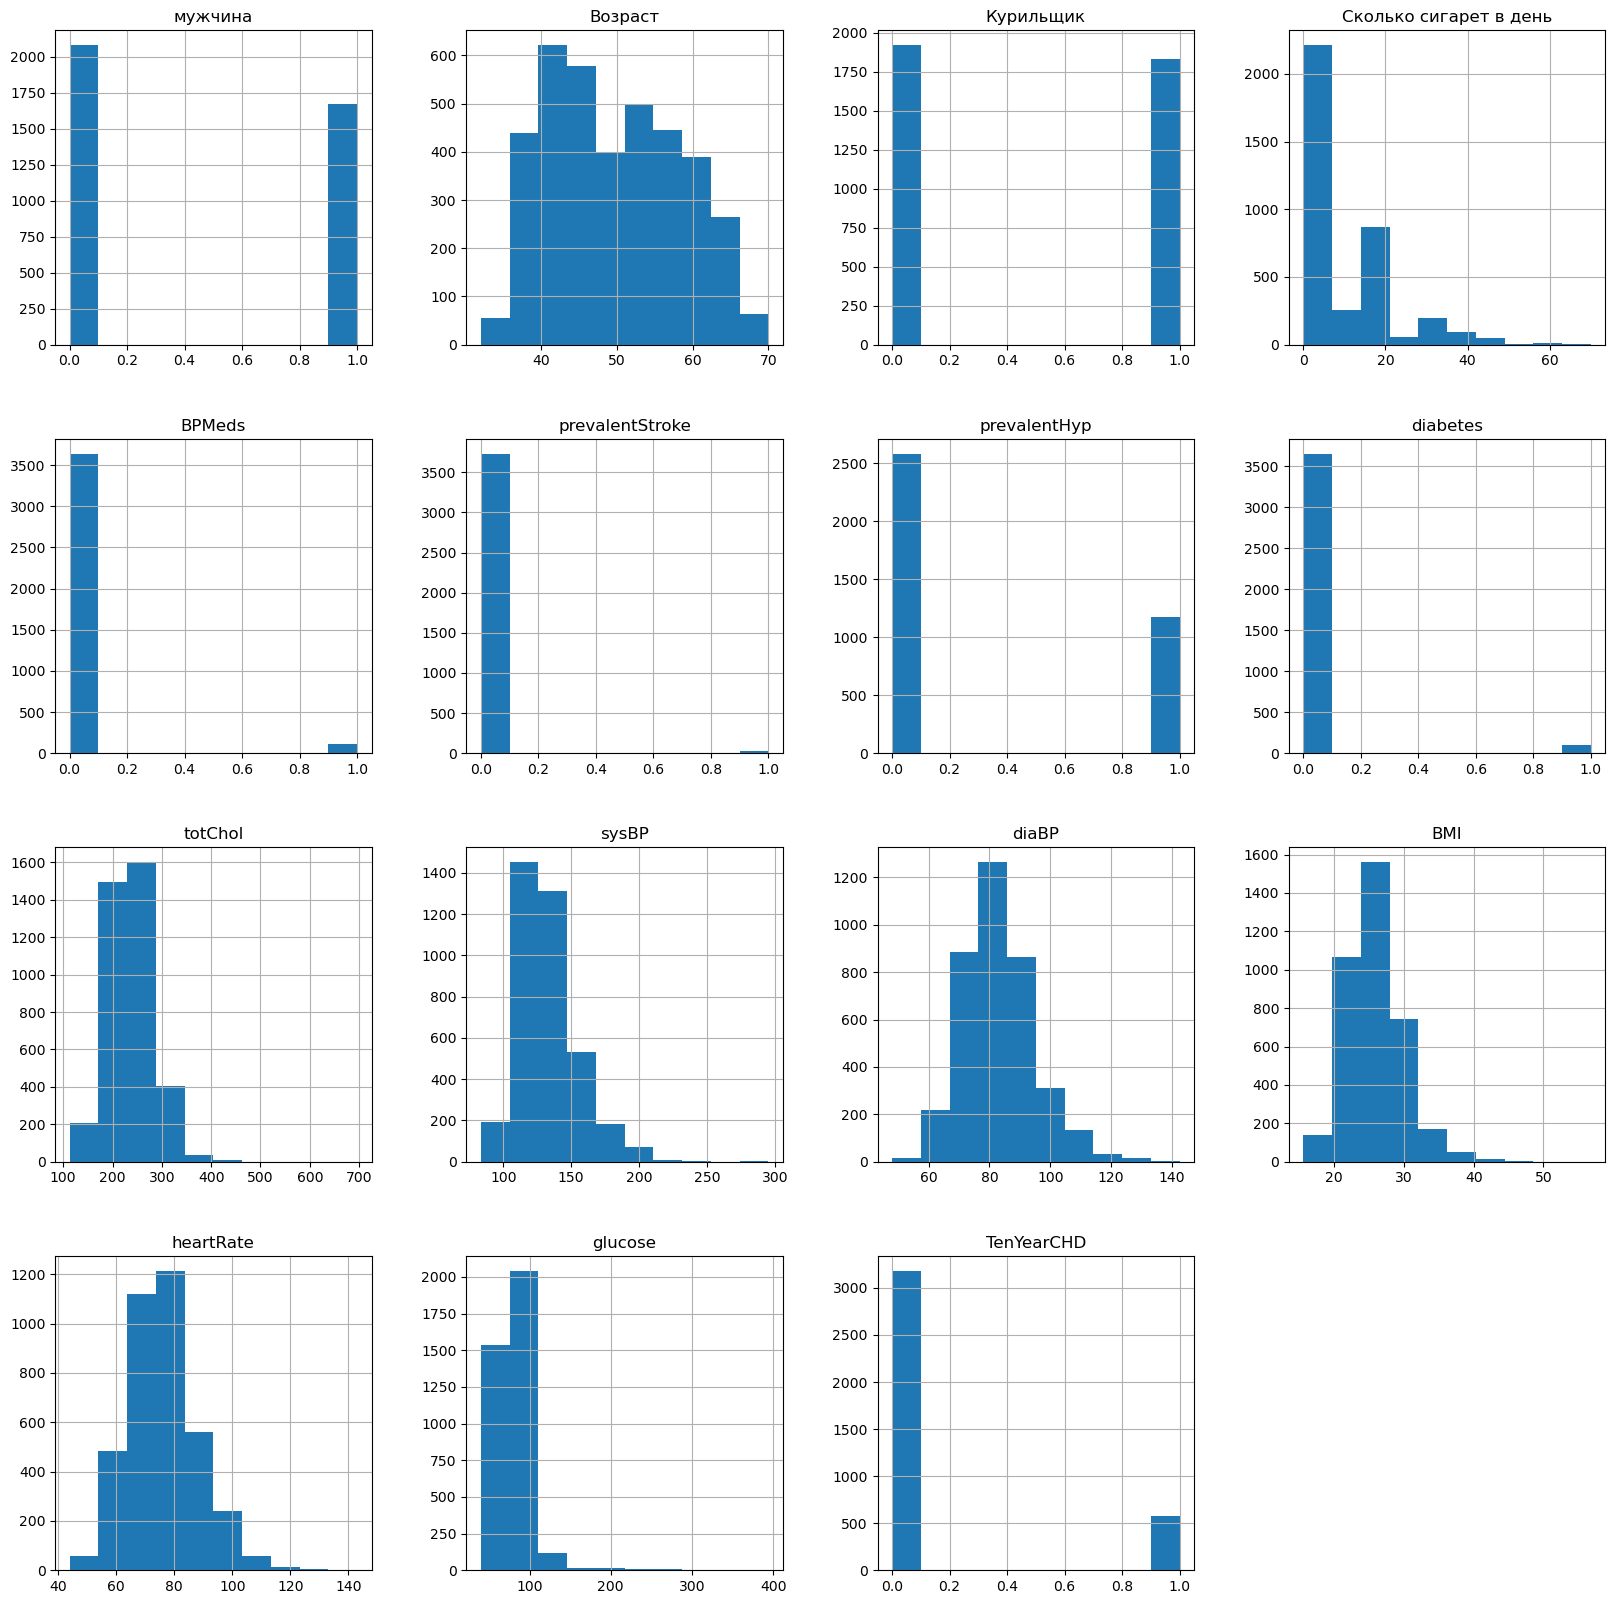

In [15]:
heart_df.hist(figsize=(20, 20));

<Axes: xlabel='TenYearCHD', ylabel='count'>

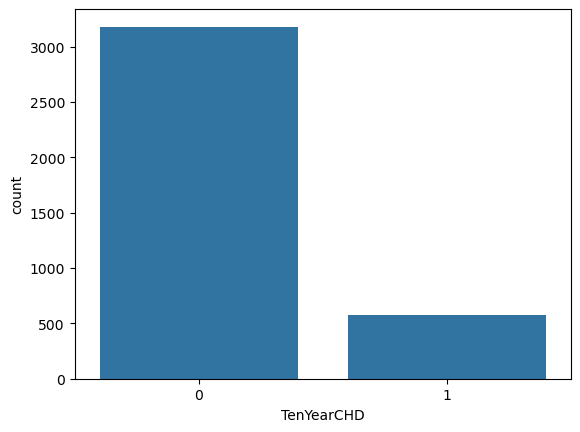

In [7]:
sns.countplot(x='TenYearCHD', data=heart_df)

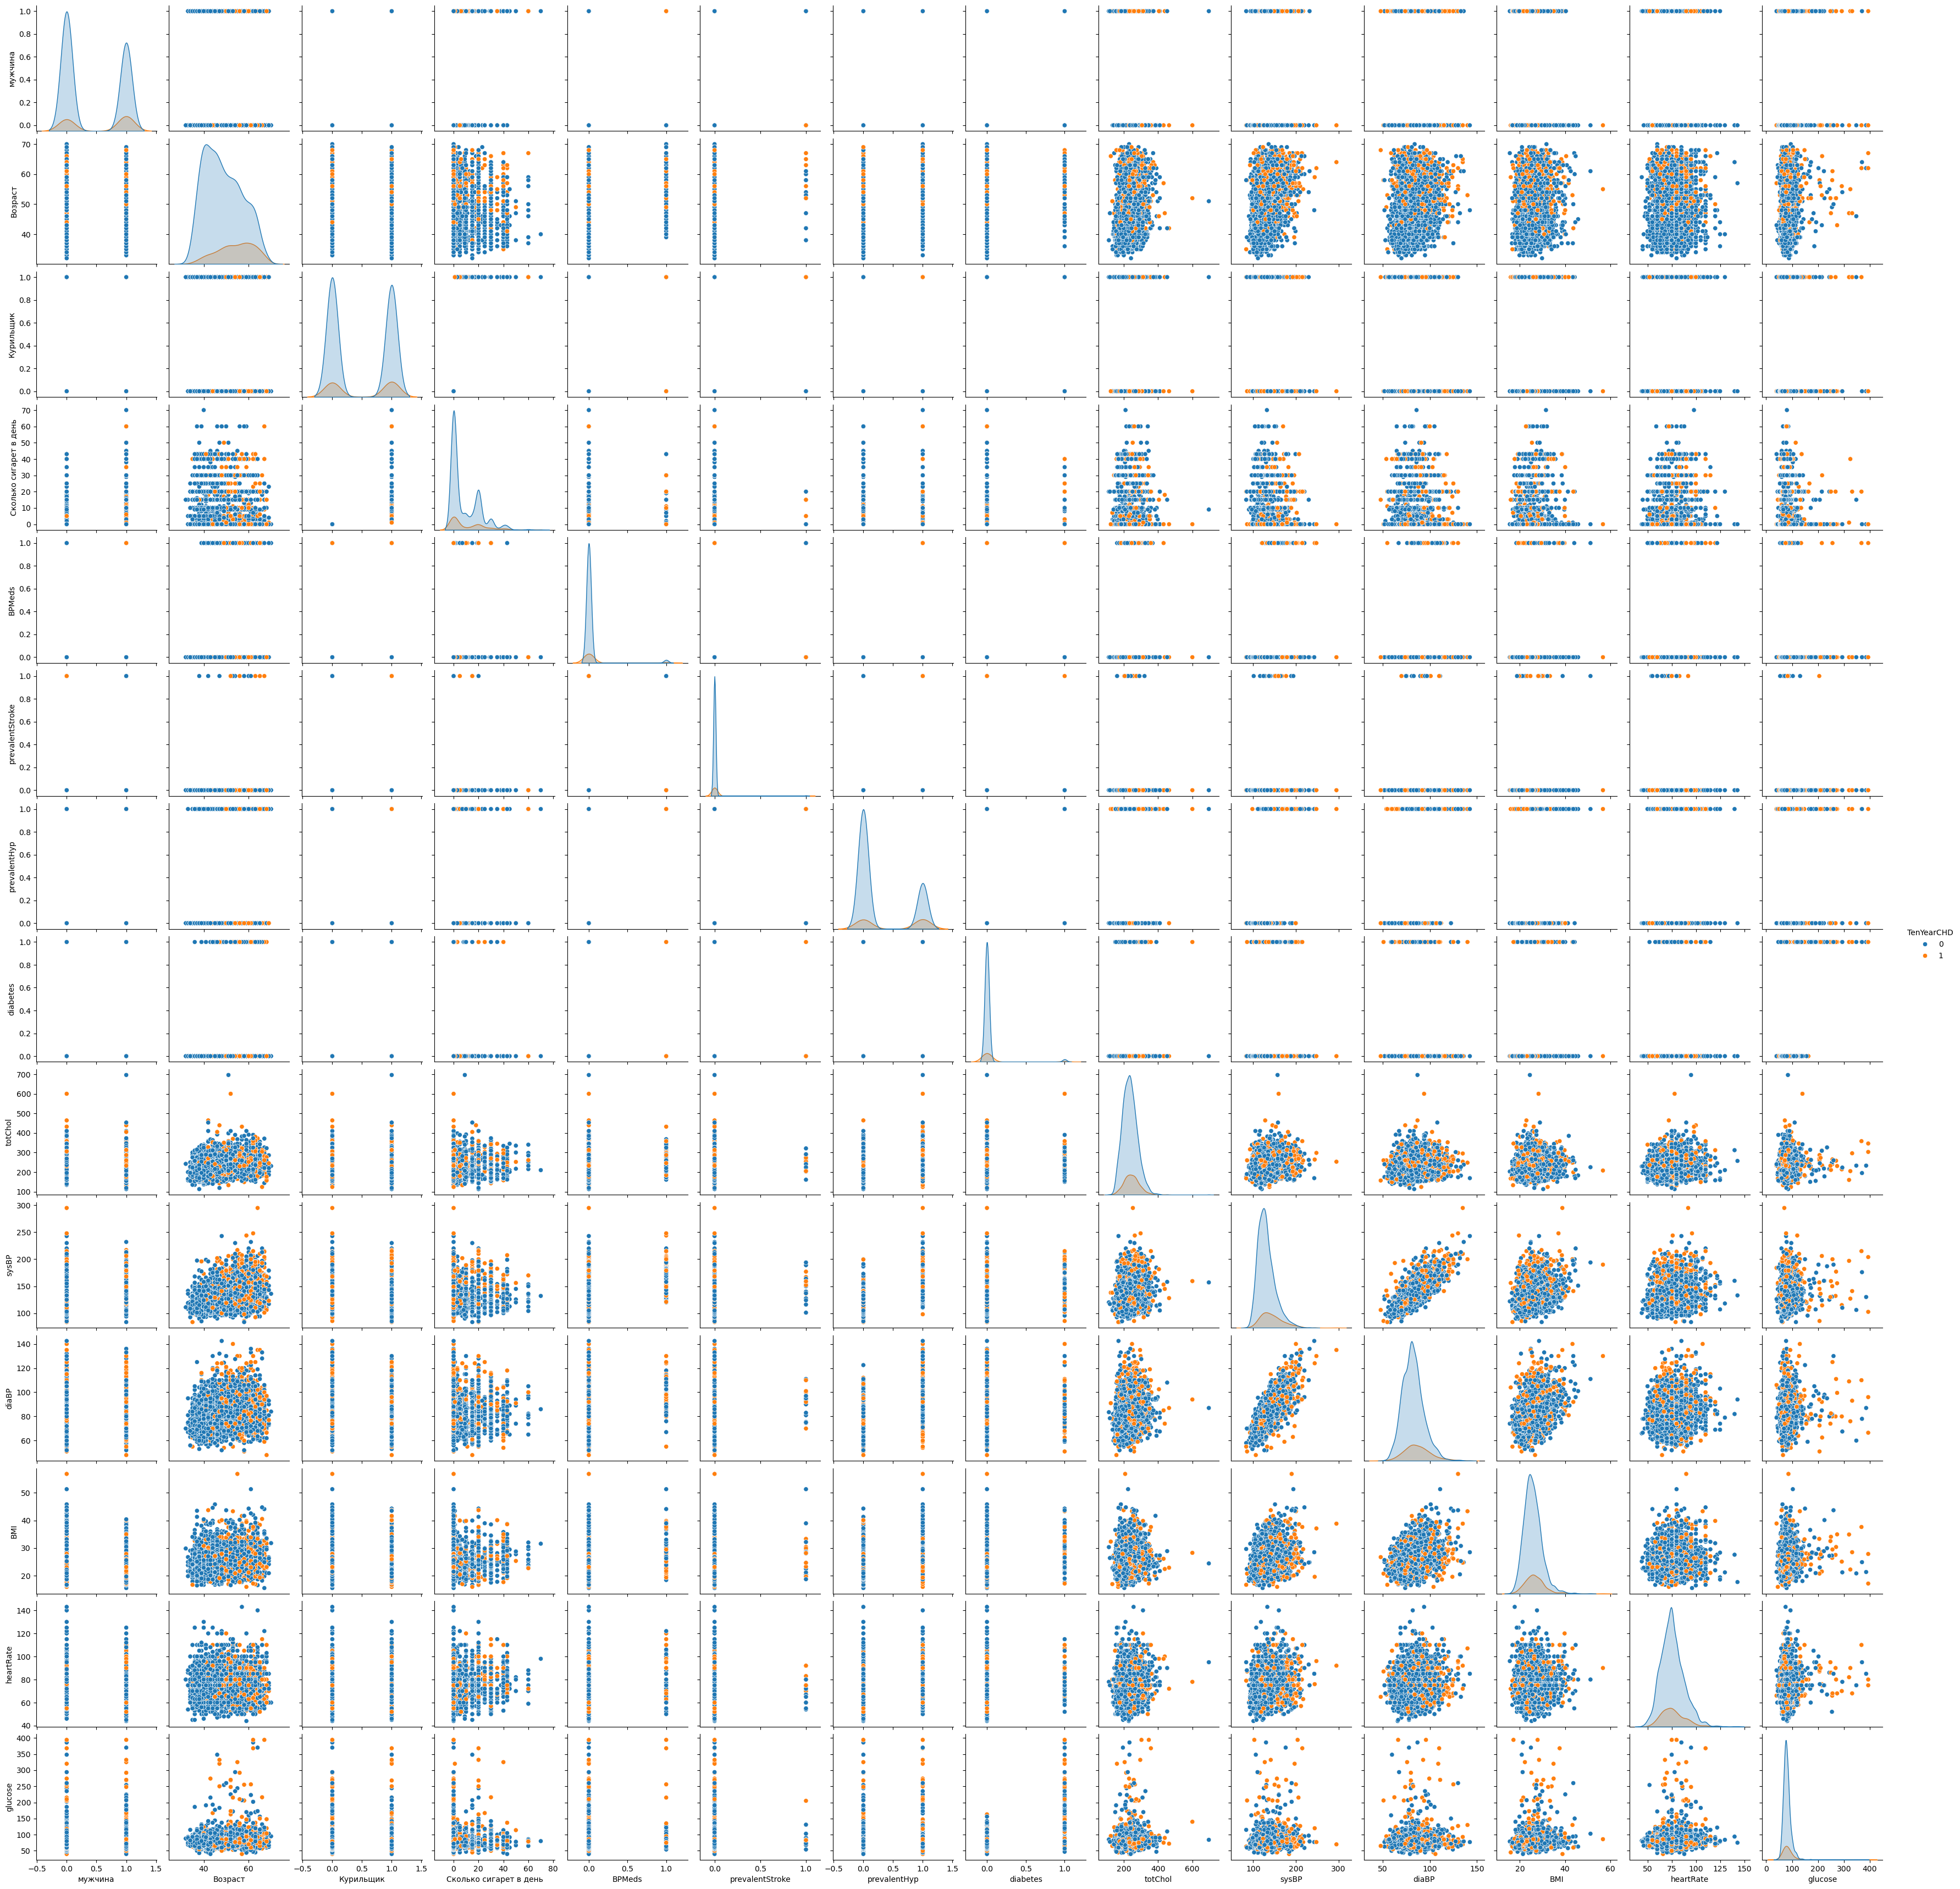

In [17]:
sns.pairplot(data=heart_df, hue='TenYearCHD')

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

In [9]:
def quality_report(prediction, actual):
    print("Accuracy: {:.3f}\nPrecission: {:.3f}\nRecall: {:.3f}\nf1_score: {:.3f}".format(
        accuracy_score(prediction, actual),
        precision_score(prediction, actual),
        recall_score(prediction, actual),
        f1_score(prediction, actual)
    ))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    heart_df.drop(['TenYearCHD'], axis=1),
    heart_df['TenYearCHD'],
    test_size=0.20,
    random_state=42,
    stratify=heart_df['TenYearCHD']
)

# Стандартизируем
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [11]:
log_reg = LogisticRegression()

log_reg.fit(X_train_scaled, y_train)
print("Train quality: ")
quality_report(log_reg.predict(X_train_scaled), y_train)
print("\nTest quality: ")
quality_report(log_reg.predict(X_test_scaled), y_test)

Train quality: 
Accuracy: 0.855
Precission: 0.098
Recall: 0.652
f1_score: 0.171

Test quality: 
Accuracy: 0.848
Precission: 0.052
Recall: 0.545
f1_score: 0.095


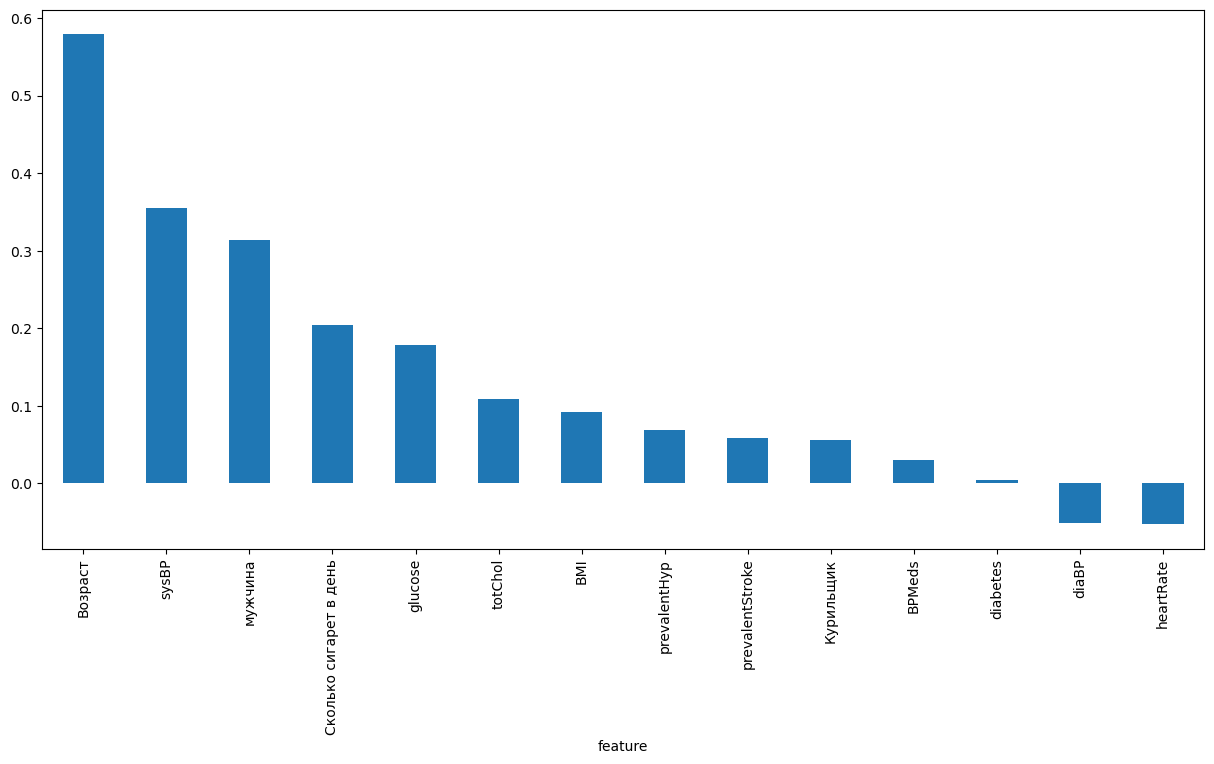

In [12]:
featureImportance = pd.DataFrame({"feature": heart_df.drop('TenYearCHD', axis=1).columns,
                                  "importance": log_reg.coef_[0]})

featureImportance.set_index('feature', inplace=True)
featureImportance.sort_values(["importance"], ascending=False, inplace=True)
featureImportance["importance"].plot(kind='bar', figsize=(15, 7));

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve

def plot_roc_curve(prob_prediction, actual):
    fpr, tpr, thresholds = roc_curve(y_test, prob_prediction)
    auc_score = roc_auc_score(y_test, prob_prediction)

    plt.plot(fpr, tpr, label='ROC curve')
    plt.plot([0,1], [0, 1])
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC: {:.3f}'.format(auc_score))
    plt.show()

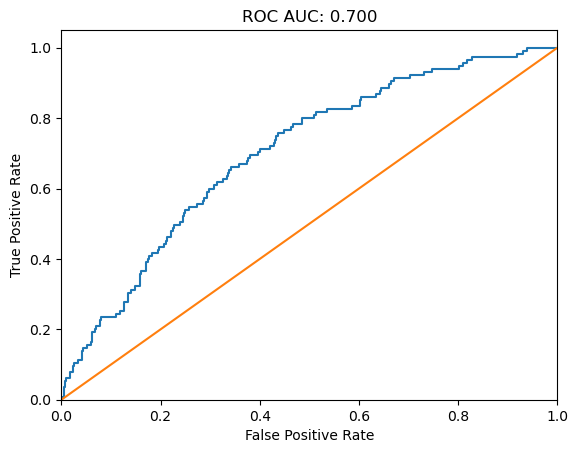

In [16]:
plot_roc_curve(log_reg.predict_proba(X_test_scaled)[:, 1], y_test)

In [17]:
log_reg_cv = LogisticRegressionCV(Cs=100)
log_reg_cv.fit(X_train_scaled, y_train)
print("Train quality:")
quality_report(log_reg_cv.predict(X_train_scaled), y_train)
print("\nTest quality:")
quality_report(log_reg_cv.predict(X_test_scaled), y_test)

Train quality:
Accuracy: 0.856
Precission: 0.083
Recall: 0.731
f1_score: 0.149

Test quality:
Accuracy: 0.847
Precission: 0.043
Recall: 0.500
f1_score: 0.080


<Axes: >

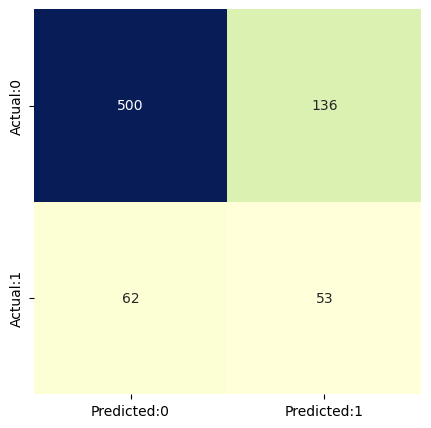

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_reg_cv.predict_proba(X_test_scaled)[:, 1]>0.2)

conf_matrix = pd.DataFrame(data=cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0','Actual:1'])
plt.figure(figsize=(5,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=False)

# Эконометрический подход

In [32]:
import statsmodels.api as sm

In [33]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=heart_df.columns[:-1])

In [34]:
X_train_scaled.head()

,мужчина,Возраст,Курильщик,Сколько сигарет в день,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1.124345,-0.299919,1.016130,0.932259,-0.182794,-0.079835,-0.678125,-0.170762,1.052853,0.210323,0.684277,0.375505,-0.216992,-0.870632
1,1.124345,-0.880182,1.016130,0.932259,-0.182794,-0.079835,1.474654,-0.170762,0.516511,-0.017472,0.261997,0.976408,-0.049258,-0.662603
2,-0.889407,-0.764129,1.016130,0.932259,-0.182794,-0.079835,-0.678125,-0.170762,-1.651201,-1.270344,-1.511580,-1.971231,-0.049258,-0.454573
3,-0.889407,0.512450,-0.984126,-0.753359,-0.182794,-0.079835,1.474654,-0.170762,1.455109,3.536128,3.766922,1.525381,-0.636327,-0.121725
4,1.124345,1.208766,-0.984126,-0.753359,-0.182794,-0.079835,-0.678125,-0.170762,-1.204250,-0.837533,-1.089300,-0.556760,-0.049258,-0.953844


In [35]:
model = sm.Logit(y_train.values, X_train_scaled)
result = model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2986
Method:                           MLE   Df Model:                           13
Date:                Wed, 10 Jun 2026   Pseudo R-squ.:                 -0.5561
Time:                        13:05:51   Log-Likelihood:                -1992.2
converged:                       True   LL-Null:                       -1280.2
Covariance Type:            nonrobust   LLR p-value:                     1.000
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
мужчина                    0.1377      0.041      3.366      0.001       0.058       0.218
Возраст                    0.2656      0.044      6.103      0.000       0.180       0.351
Курильщик                  0.0300      0.060      0.503      0.615      -0.087       0.147
Сколько сигарет в день     0.1031      0.061      1.687      0.092      -0.017       0.223
BPMeds                     0.0398      0.042      0.953      0.341      -0.042       0.122
prevalentStroke            0.0504      0.042      1.206      0.228      -0.031       0.132
prevalentHyp               0.0258      0.054      0.478      0.632      -0.080       0.132
diabetes                   0.0218      0.050      0.439      0.660      -0.076       0.119
totChol                    0.0226      0.040      0.568      0.570      -0.055       0.101
sysBP                      0.2515      0.075      3.345      0.001       0.104       0.399
diaBP                     -0.0674      0.066     -1.027      0.304      -0.196       0.061
BMI                        0.0326      0.042      0.779      0.436      -0.049       0.115
heartRate                 -0.0231      0.040     -0.584      0.559      -0.101       0.054
glucose                    0.1405      0.054      2.600      0.009       0.035       0.246
==========================================================================================
"""

In [36]:
np.argmax(result.pvalues)

np.int64(7)

In [37]:
result.pvalues.max()

0.6603647656516469

In [38]:
col = X_train_scaled.columns
col

Index(['мужчина', 'Возраст', 'Курильщик', 'Сколько сигарет в день', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose'],
      dtype='object')

In [41]:
model = sm.Logit(y_train.values, X_train_scaled)
result = model.fit()
result.summary()
col = X_train_scaled.columns

for iteration in range(len(col)):
    
    model = sm.Logit(y_train.values, X_train_scaled[col])
    result = model.fit()
    
    potentially_bad = np.argmax(result.pvalues)
    
    if result.pvalues.max() > 0.05:
        col = [c for c in col if c != potentially_bad]

Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664062
  

In [42]:
 result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2986
Method:                           MLE   Df Model:                           13
Date:                Wed, 10 Jun 2026   Pseudo R-squ.:                 -0.5561
Time:                        13:07:52   Log-Likelihood:                -1992.2
converged:                       True   LL-Null:                       -1280.2
Covariance Type:            nonrobust   LLR p-value:                     1.000
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
мужчина                    0.1377      0.041      3.366      0.001       0.058       0.218
Возраст                    0.2656      0.044      6.103      0.000       0.180       0.351
Курильщик                  0.0300      0.060      0.503      0.615      -0.087       0.147
Сколько сигарет в день     0.1031      0.061      1.687      0.092      -0.017       0.223
BPMeds                     0.0398      0.042      0.953      0.341      -0.042       0.122
prevalentStroke            0.0504      0.042      1.206      0.228      -0.031       0.132
prevalentHyp               0.0258      0.054      0.478      0.632      -0.080       0.132
diabetes                   0.0218      0.050      0.439      0.660      -0.076       0.119
totChol                    0.0226      0.040      0.568      0.570      -0.055       0.101
sysBP                      0.2515      0.075      3.345      0.001       0.104       0.399
diaBP                     -0.0674      0.066     -1.027      0.304      -0.196       0.061
BMI                        0.0326      0.042      0.779      0.436      -0.049       0.115
heartRate                 -0.0231      0.040     -0.584      0.559      -0.101       0.054
glucose                    0.1405      0.054      2.600      0.009       0.035       0.246
==========================================================================================
"""